In [1]:
# Prueba del kernel
import pandas as pd
import mysql.connector

print("Kernel listo")

Kernel listo


In [2]:
# Conexion a la base de datos
from getpass import getpass

conexion = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password=getpass("Contraseña de MySQL: "),
    database="classicmodels"
)

# Consulta de prueba
cursor = conexion.cursor()
cursor.execute("SHOW TABLES")
tablas = pd.DataFrame(cursor.fetchall(), columns=["tabla"])
cursor.close()

tablas

,tabla
0,customers
1,employees
2,offices
3,orderdetails
4,orders
5,payments
6,productlines
7,products


In [3]:
# Funcion para traer una consulta como DataFrame
def consultar(sql):
    cursor = conexion.cursor()
    cursor.execute(sql)
    columnas = [c[0] for c in cursor.description]
    datos = pd.DataFrame(cursor.fetchall(), columns=columnas)
    cursor.close()
    return datos

# Cargar las tablas principales
customers = consultar("SELECT * FROM customers")
orders = consultar("SELECT * FROM orders")
orderdetails = consultar("SELECT * FROM orderdetails")
products = consultar("SELECT * FROM products")
payments = consultar("SELECT * FROM payments")
employees = consultar("SELECT * FROM employees")
offices = consultar("SELECT * FROM offices")

# Cantidad de filas y columnas por tabla
for nombre, df in [("customers", customers), ("orders", orders),
                   ("orderdetails", orderdetails), ("products", products),
                   ("payments", payments), ("employees", employees),
                   ("offices", offices)]:
    print(nombre, df.shape)

# Convertir columnas Decimal a numero
from decimal import Decimal

for df in [customers, orders, orderdetails, products, payments, employees, offices]:
    for col in df.columns:
        if df[col].map(lambda v: isinstance(v, Decimal)).any():
            df[col] = df[col].astype(float)

print(products.dtypes)

customers (122, 13)
orders (326, 7)
orderdetails (2996, 5)
products (110, 9)
payments (273, 4)
employees (23, 8)
offices (7, 9)
productCode               str
productName               str
productLine               str
productScale              str
productVendor             str
productDescription        str
quantityInStock         int64
buyPrice              float64
MSRP                  float64
dtype: object


# Análisis univariado


In [4]:
# Librerias de graficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Gráfico 1: Límite de crédito de los clientes (creditLimit)

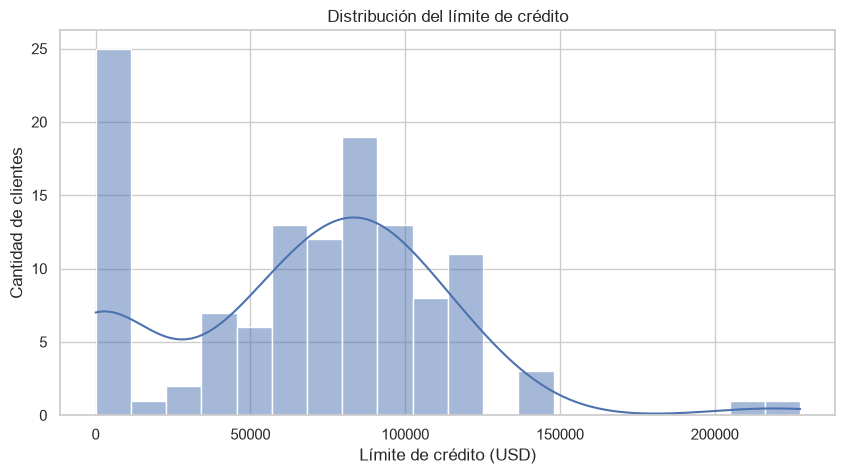

count       122.000000
mean      67659.016393
std       45043.370751
min           0.000000
25%       42175.000000
50%       76700.000000
75%       95075.000000
max      227600.000000
Name: creditLimit, dtype: float64

In [5]:
# Distribucion del limite de credito
sns.histplot(customers["creditLimit"], bins=20, kde=True)
plt.title("Distribución del límite de crédito")
plt.xlabel("Límite de crédito (USD)")
plt.ylabel("Cantidad de clientes")
plt.show()

customers["creditLimit"].describe()

In [6]:
# Clientes sin credito
sin_credito = (customers["creditLimit"] == 0).sum()
print("Clientes con crédito 0:", sin_credito)
print("Porcentaje:", round(sin_credito / len(customers) * 100, 1), "%")

Clientes con crédito 0: 24
Porcentaje: 19.7 %


**Interpretación:** La mayoría de los clientes tiene un límite de crédito entre 42.175 y 95.075 USD, con una mediana de 76.700 USD. Llama la atención la barra en 0: 24 clientes (19,7 %) no tienen crédito aprobado. Estos ceros bajan el promedio a 67.659 USD, por eso la mediana representa mejor al cliente típico. También hay unos pocos clientes con créditos muy altos, cerca de 227.600 USD, que son casos fuera de lo común. Para el negocio, los clientes sin crédito podrían ser clientes nuevos o de riesgo, y valdría la pena revisar si se les puede ofrecer crédito para aumentar las ventas.

## Gráfico 2: País de los clientes (country)

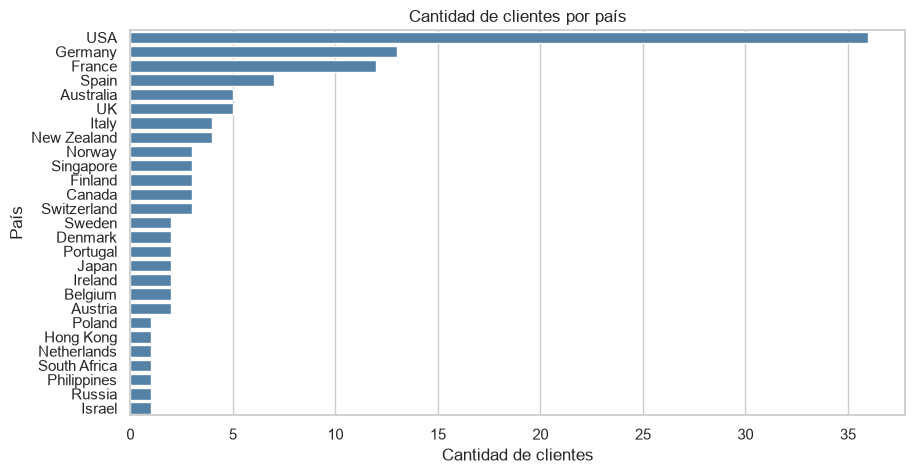

Total de países: 27


country
USA          36
Germany      13
France       12
Spain         7
Australia     5
Name: count, dtype: int64

In [7]:
# Cantidad de clientes por pais
conteo_pais = customers["country"].str.strip().value_counts()

sns.barplot(x=conteo_pais.values, y=conteo_pais.index, color="steelblue")
plt.title("Cantidad de clientes por país")
plt.xlabel("Cantidad de clientes")
plt.ylabel("País")
plt.show()

print("Total de países:", conteo_pais.size)
conteo_pais.head(5)

**Interpretación:** Los clientes están en 27 países, pero muy concentrados. Estados Unidos es el mercado principal con 36 clientes (cerca del 30 %), seguido de Alemania (13) y Francia (12). Entre estos tres países suman 61 clientes, es decir, la mitad del total. Europa también tiene mucho peso, con varios países en la lista. En cambio, países como Polonia, Rusia o Israel solo tienen 1 o 2 clientes. Durante la revisión encontramos que "Norway" aparecía dos veces por espacios de más en el nombre, y lo corregimos con `str.strip()`. Para el negocio, depender tanto de Estados Unidos es un riesgo, y los países con pocos clientes podrían ser una oportunidad para crecer.

## Gráfico 3: Precio de compra de los productos (buyPrice)

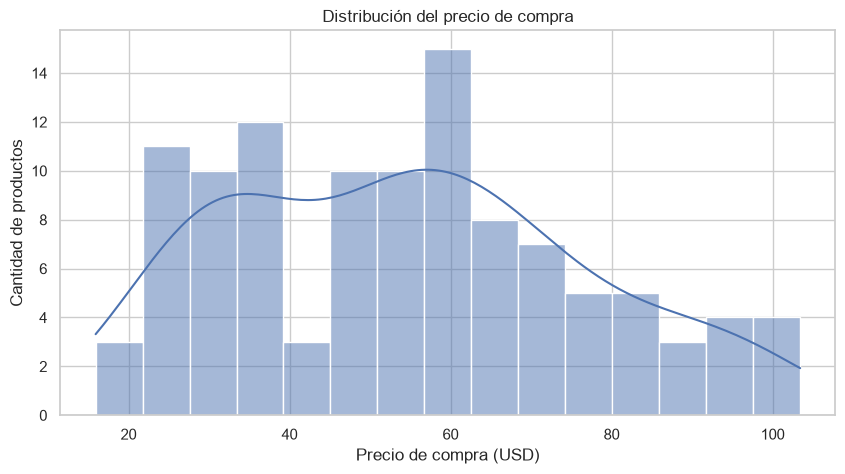

count    110.000000
mean      54.395182
std       22.051130
min       15.910000
25%       34.180000
50%       53.915000
75%       68.675000
max      103.420000
Name: buyPrice, dtype: float64

In [8]:
# Distribucion del precio de compra
sns.histplot(products["buyPrice"], bins=15, kde=True)
plt.title("Distribución del precio de compra")
plt.xlabel("Precio de compra (USD)")
plt.ylabel("Cantidad de productos")
plt.show()

products["buyPrice"].describe()

**Interpretación:** Los 110 productos tienen un precio de compra entre 15,91 y 103,42 USD. El promedio (54,40 USD) y la mediana (53,92 USD) son casi iguales, lo que indica que los precios están bastante equilibrados y no hay valores extremos. La mitad de los productos cuesta entre 34,18 y 68,68 USD, y el grupo más grande está cerca de los 60 USD. Hay pocos productos caros (más de 80 USD), por eso la gráfica baja hacia la derecha. Para el negocio, esto muestra que el catálogo se enfoca en productos de precio medio, y los productos más caros podrían revisarse para saber si dejan más ganancia.

## Gráfico 4: Unidades en inventario (quantityInStock)

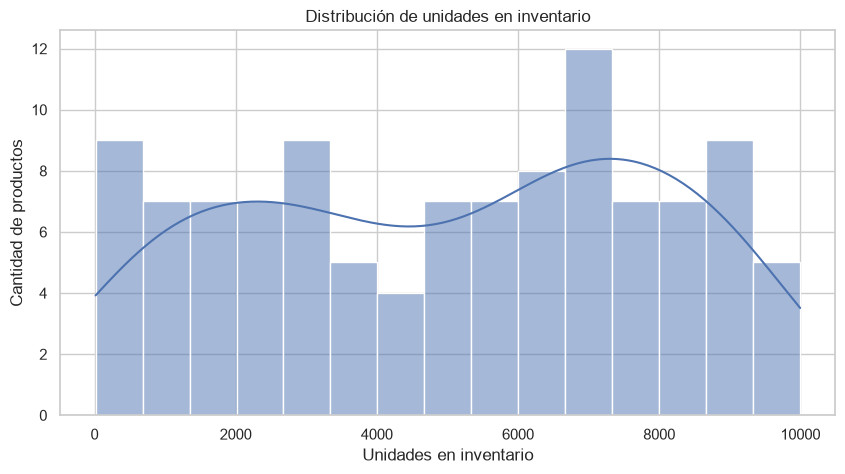

Productos con menos de 1000 unidades: 12


count     110.000000
mean     5046.645455
std      2939.263668
min        15.000000
25%      2419.000000
50%      5437.500000
75%      7599.750000
max      9997.000000
Name: quantityInStock, dtype: float64

In [9]:
# Distribucion del inventario
sns.histplot(products["quantityInStock"], bins=15, kde=True)
plt.title("Distribución de unidades en inventario")
plt.xlabel("Unidades en inventario")
plt.ylabel("Cantidad de productos")
plt.show()

# Productos con poco inventario
poco_stock = (products["quantityInStock"] < 1000).sum()
print("Productos con menos de 1000 unidades:", poco_stock)

products["quantityInStock"].describe()

**Interpretación:** El inventario de los 110 productos va de 15 a 9.997 unidades. El promedio (5.047) y la mediana (5.438) están cerca, y las barras tienen alturas parecidas en todo el rango, lo que muestra que el inventario está repartido de forma bastante pareja entre los productos. La mitad de los productos tiene entre 2.419 y 7.600 unidades. Sin embargo, 12 productos (cerca del 11 %) tienen menos de 1.000 unidades, y uno tiene apenas 15. Para el negocio, esos productos con poco inventario podrían agotarse pronto, por lo que conviene revisar si se venden mucho y reabastecerlos a tiempo.

## Gráfico 5: Línea de producto (productLine)

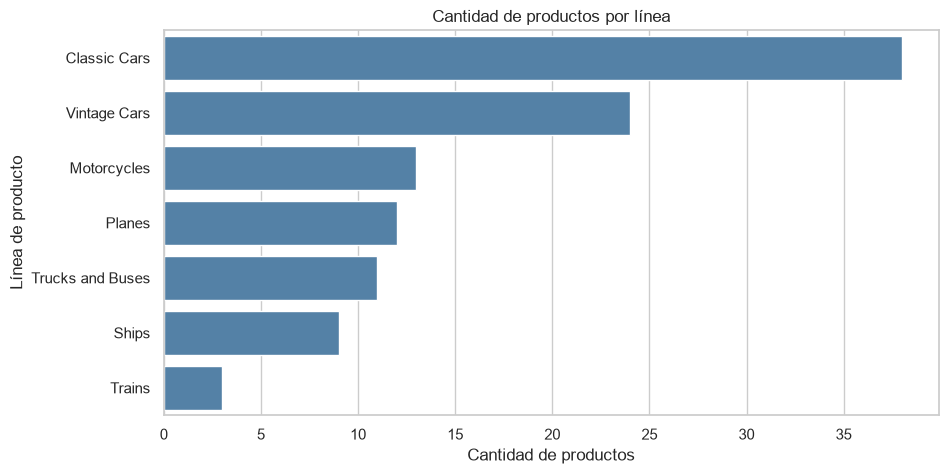

Total de líneas: 7


productLine
Classic Cars        38
Vintage Cars        24
Motorcycles         13
Planes              12
Trucks and Buses    11
Ships                9
Trains               3
Name: count, dtype: int64

In [10]:
# Cantidad de productos por linea
conteo_linea = products["productLine"].str.strip().value_counts()

sns.barplot(x=conteo_linea.values, y=conteo_linea.index, color="steelblue")
plt.title("Cantidad de productos por línea")
plt.xlabel("Cantidad de productos")
plt.ylabel("Línea de producto")
plt.show()

print("Total de líneas:", conteo_linea.size)
conteo_linea

**Interpretación:** Los 110 productos se dividen en 7 líneas. La más grande es Classic Cars con 38 productos (cerca del 35 %), seguida de Vintage Cars con 24. Entre las dos suman 62 productos, más de la mitad del catálogo, lo que muestra que la empresa se enfoca en carros a escala. Después vienen Motorcycles (13), Planes (12), Trucks and Buses (11) y Ships (9). Trains es la línea más pequeña, con solo 3 productos. Para el negocio, conviene revisar si las líneas con menos productos venden poco por falta de variedad, y si vale la pena ampliarlas o enfocarse en los carros, que son el fuerte.

## Gráfico 6: Escala de los productos (productScale)

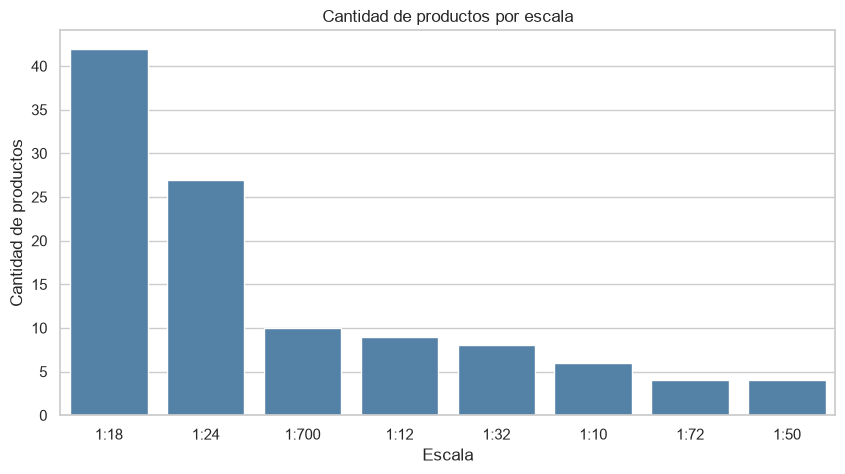

Total de escalas: 8


productScale
1:18     42
1:24     27
1:700    10
1:12      9
1:32      8
1:10      6
1:72      4
1:50      4
Name: count, dtype: int64

In [11]:
# Cantidad de productos por escala
conteo_escala = products["productScale"].str.strip().value_counts()

sns.barplot(x=conteo_escala.index, y=conteo_escala.values, color="steelblue")
plt.title("Cantidad de productos por escala")
plt.xlabel("Escala")
plt.ylabel("Cantidad de productos")
plt.show()

print("Total de escalas:", conteo_escala.size)
conteo_escala

**Interpretación:** Los productos se fabrican en 8 escalas distintas. La más común es 1:18, con 42 productos (cerca del 38 %), seguida de 1:24 con 27. Entre las dos suman 69 productos, casi dos de cada tres. Esto tiene sentido con el Gráfico 5, porque son escalas muy usadas en carros a escala, que son la línea principal. Las escalas menos comunes son 1:72 y 1:50, con 4 productos cada una. Hay que tener en cuenta que entre más grande el segundo número, más pequeño es el modelo (1:10 es grande y 1:700 es muy pequeño). Para el negocio, la empresa se enfoca en modelos de tamaño mediano a grande, y las escalas poco usadas podrían ser una oportunidad para clientes coleccionistas.

## Gráfico 7: Estado de los pedidos (status)

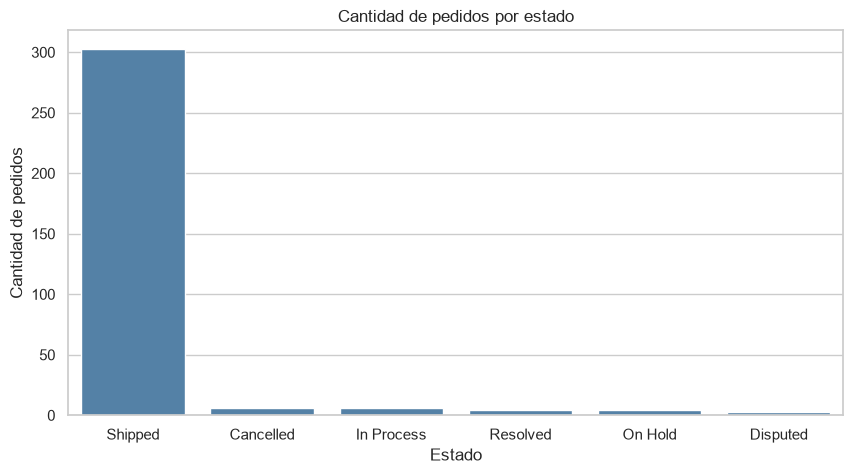

,pedidos,porcentaje
status,,
Shipped,303,92.9
Cancelled,6,1.8
In Process,6,1.8
Resolved,4,1.2
On Hold,4,1.2
Disputed,3,0.9


In [12]:
# Cantidad de pedidos por estado
conteo_estado = orders["status"].str.strip().value_counts()

sns.barplot(x=conteo_estado.index, y=conteo_estado.values, color="steelblue")
plt.title("Cantidad de pedidos por estado")
plt.xlabel("Estado")
plt.ylabel("Cantidad de pedidos")
plt.show()

# Porcentaje por estado
porcentaje = (conteo_estado / conteo_estado.sum() * 100).round(1)
pd.DataFrame({"pedidos": conteo_estado, "porcentaje": porcentaje})

**Interpretación:** De los 326 pedidos, 303 fueron enviados (92,9 %), lo que muestra que la empresa completa la gran mayoría de sus ventas. Los demás estados son pocos: 6 cancelados (1,8 %), 6 en proceso (1,8 %), 4 resueltos (1,2 %), 4 retenidos (1,2 %) y 3 en disputa (0,9 %). Como la barra de "Shipped" es tan alta, los otros estados casi no se ven en el gráfico, por eso la tabla de porcentajes ayuda a leerlos. Si sumamos cancelados, retenidos y en disputa, 13 pedidos (4 %) tuvieron algún problema. Para el negocio, es un porcentaje bajo, pero vale la pena revisar las causas de esos casos para evitar perder clientes o dinero.

## Gráfico 8: Pedidos por mes (orderDate)

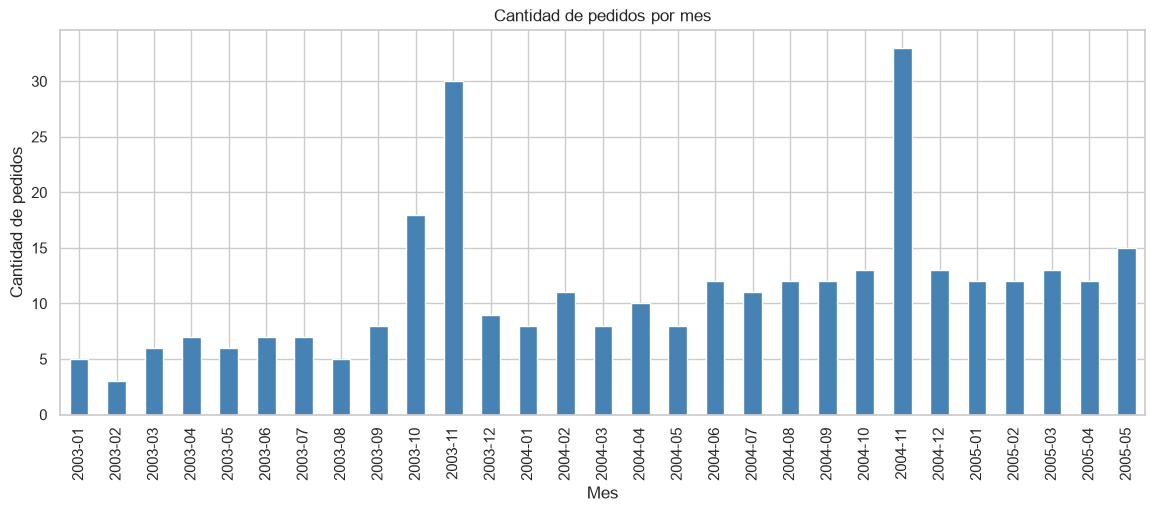

Primer pedido: 2003-01-06
Último pedido: 2005-05-31

Meses con más pedidos:
orderDate
2004-11    33
2003-11    30
2003-10    18
Freq: M, Name: count, dtype: int64

Pedidos por año:


orderDate
2003    111
2004    151
2005     64
Name: count, dtype: int64

In [13]:
# Cantidad de pedidos por mes
fechas = pd.to_datetime(orders["orderDate"])
pedidos_mes = fechas.dt.to_period("M").value_counts().sort_index()

pedidos_mes.plot(kind="bar", color="steelblue", figsize=(14, 5))
plt.title("Cantidad de pedidos por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de pedidos")
plt.xticks(rotation=90)
plt.show()

print("Primer pedido:", fechas.min().date())
print("Último pedido:", fechas.max().date())
print("\nMeses con más pedidos:")
print(pedidos_mes.sort_values(ascending=False).head(3))
print("\nPedidos por año:")
fechas.dt.year.value_counts().sort_index()

**Interpretación:** Los pedidos van del 6 de enero de 2003 al 31 de mayo de 2005. Hay que tener cuidado al comparar años, porque 2005 solo tiene datos de 5 meses. Entre los años completos, los pedidos crecieron de 111 en 2003 a 151 en 2004, cerca de un 36 % más. En 2005 hubo 64 pedidos en 5 meses, unos 12,8 por mes, un ritmo parecido al de 2004 (12,6 por mes). Lo que más llama la atención son los picos de noviembre: 30 pedidos en 2003 y 33 en 2004, los meses con más ventas. Como se repite cada año, parece un comportamiento de temporada, probablemente por las compras de fin de año. Para el negocio, conviene preparar inventario y personal antes de octubre y noviembre para atender ese aumento.

## Gráfico 9: Unidades pedidas por producto (quantityOrdered)

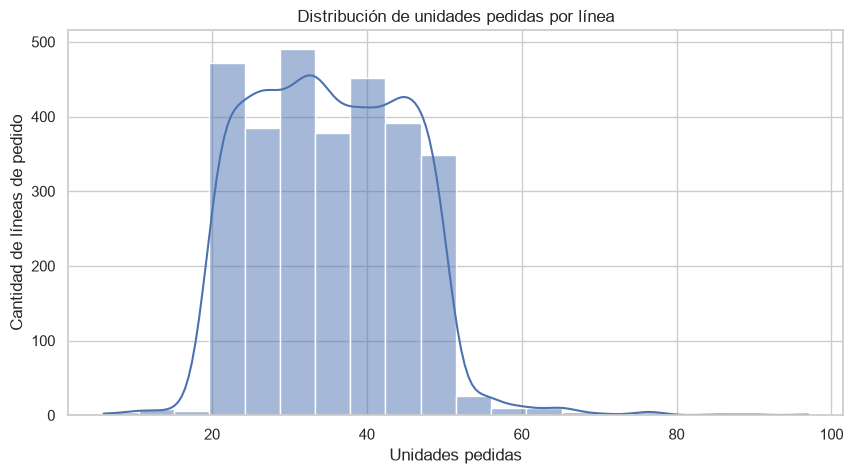

count    2996.000000
mean       35.218959
std         9.833885
min         6.000000
25%        27.000000
50%        35.000000
75%        43.000000
max        97.000000
Name: quantityOrdered, dtype: float64

In [14]:
# Distribucion de unidades pedidas
sns.histplot(orderdetails["quantityOrdered"], bins=20, kde=True)
plt.title("Distribución de unidades pedidas por línea")
plt.xlabel("Unidades pedidas")
plt.ylabel("Cantidad de líneas de pedido")
plt.show()

orderdetails["quantityOrdered"].describe()

**Interpretación:** En las 2.996 líneas de pedido se piden entre 6 y 97 unidades por producto. El promedio (35,2) y la mediana (35) son casi iguales, lo que muestra que las cantidades están equilibradas. La mitad de las líneas pide entre 27 y 43 unidades, y casi todas están entre 20 y 50. Después de 50 unidades la gráfica cae de golpe, y solo hay unos pocos pedidos grandes, de hasta 97 unidades. Esto indica que los clientes compran al por mayor, en cantidades bastante parecidas. Para el negocio, este rango sirve para planear el inventario, y los pedidos muy grandes podrían ser clientes especiales a los que vale la pena ofrecer descuentos por volumen.

## Gráfico 10: Monto de los pagos (amount)

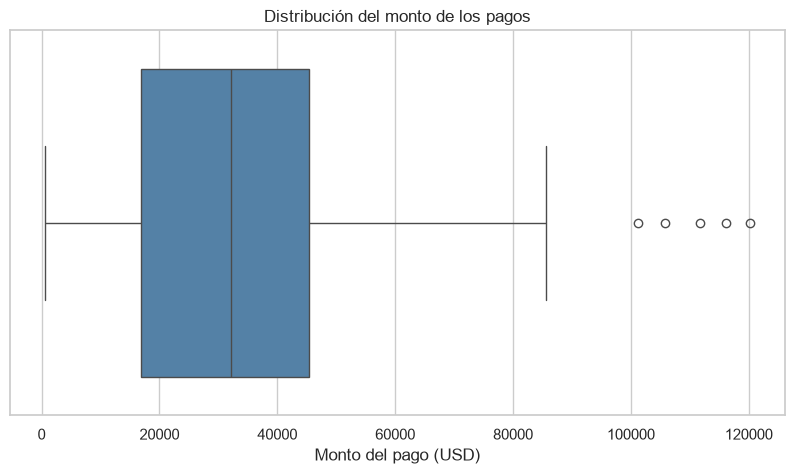

Límite de valores atípicos: 88016.42
Pagos atípicos: 5


count       273.000000
mean      32431.645531
std       20997.116917
min         615.450000
25%       16909.840000
50%       32077.440000
75%       45352.470000
max      120166.580000
Name: amount, dtype: float64

In [15]:
# Distribucion del monto de los pagos
sns.boxplot(x=payments["amount"], color="steelblue")
plt.title("Distribución del monto de los pagos")
plt.xlabel("Monto del pago (USD)")
plt.show()

# Contar pagos atipicos
q1 = payments["amount"].quantile(0.25)
q3 = payments["amount"].quantile(0.75)
limite = q3 + 1.5 * (q3 - q1)
atipicos = (payments["amount"] > limite).sum()
print("Límite de valores atípicos:", round(limite, 2))
print("Pagos atípicos:", atipicos)

payments["amount"].describe()

**Interpretación:** Los 273 pagos van de 615,45 a 120.166,58 USD. El promedio (32.432 USD) y la mediana (32.077 USD) son muy parecidos, por lo que el pago típico ronda los 32.000 USD. La caja del gráfico muestra que la mitad de los pagos está entre 16.910 y 45.352 USD. Los puntos sueltos a la derecha son 5 pagos atípicos (1,8 %), mayores a 88.016 USD, que se salen del comportamiento normal. Para el negocio, estos pagos grandes probablemente vienen de clientes importantes, por lo que conviene identificarlos y cuidar la relación con ellos, ya que aportan mucho dinero de una sola vez.

# Análisis bivariado


## Exploración inicial / Hipótesis preliminares
_En customers estoy viendo que puedo agrupar con country y creditLimit. puede que haya una relación como que quizá le dan más crédito a personas de cierto país mientras que a otros no.

En employee puedo ver que quizá algunos empleados tengan asignados más clientes que otros y si es así. 

En office la verdad no veo mucha cosa interesante más que country.

En order podría ver cuántas órdenes hay por cliente y a qué cliente se le demora menos en hacer el ship. por ejemplo puede que haya algún cliente que repetitivamente haya menos tiempo entre orderdate y shippeddate y puede que estos clientes sean de un país en específico tremendooo.

En orderdetails podría unirlo con order yd arme cuenta qué clientes compran más en terminos de priceEach*quantityOrdered. Y quién sabe, si le meto mucha lógica podría saber si hay alguna relación entre qué tanto compra el cliente con qué tan rápido se le hace el envío.

En payments la verdad no sabría qué hacer quizá podría también darme cuenta si entre más amount tienen en sus payments, más rápido les llega el envío

En products podría preguntarme si la quantityInStock es proporcional a cómo se vende ese producto.

En product line podria preguntarme cuál es la linea a la que más le compran

En customers estoy viendo que puedo agrupar con country y creditLimit. puede que haya una relación como que quizá le dan más crédito a personas de cierto país mientras que a otros no.

En employee puedo ver que quizá algunos empleados tengan asignados más clientes que otros y si es así.

---

## Análisis bivariado 1

**Pregunta:** ¿Hay alguna relación entre el tiempo que transcurre entre `orderDate` y `shippedDate` y el país del cliente?

**Variables:**
- `dias_envio` (numérica, calculada): `shippedDate - orderDate` en días
- `country` (categórica): país del cliente

**Gráfico:** boxplot (país vs días de envío)

**Preparación:** unir `orders` con `customers` por `customerNumber`, calcular `dias_envio` y excluir pedidos sin `shippedDate` (aún no enviados).

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Unir pedidos con el país del cliente
df_biv1 = pd.merge(
    orders,
    customers[["customerNumber", "country"]],
    on="customerNumber",
    how="inner",
)

# Asegurar que las fechas sean datetime
df_biv1["orderDate"] = pd.to_datetime(df_biv1["orderDate"])
df_biv1["shippedDate"] = pd.to_datetime(df_biv1["shippedDate"])

# Variable calculada: días entre pedido y envío
df_biv1["dias_envio"] = (df_biv1["shippedDate"] - df_biv1["orderDate"]).dt.days

# Solo pedidos que ya se enviaron (tienen shippedDate)
df_biv1 = df_biv1.dropna(subset=["dias_envio"]).copy()

print("Pedidos con envío:", len(df_biv1))
print("Países distintos:", df_biv1["country"].nunique())
df_biv1[["orderNumber", "country", "orderDate", "shippedDate", "dias_envio"]].head(10)

Pedidos con envío: 312
Países distintos: 22


,orderNumber,country,orderDate,shippedDate,dias_envio
0,10100,USA,2003-01-06,2003-01-10,4.0
1,10101,Germany,2003-01-09,2003-01-11,2.0
2,10102,USA,2003-01-10,2003-01-14,4.0
3,10103,Norway,2003-01-29,2003-02-02,4.0
4,10104,Spain,2003-01-31,2003-02-01,1.0
5,10105,Denmark,2003-02-11,2003-02-12,1.0
6,10106,Italy,2003-02-17,2003-02-21,4.0
7,10107,USA,2003-02-24,2003-02-26,2.0
8,10108,Philippines,2003-03-03,2003-03-08,5.0
9,10109,USA,2003-03-10,2003-03-11,1.0


In [48]:
# Resumen numérico por país
resumen_pais = (
    df_biv1.groupby("country")["dias_envio"]
    .agg(pedidos="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)
resumen_pais


,pedidos,mediana,promedio,minimo,maximo
country,,,,,
Belgium,6,1.5,2.000000,1.0,5.0
Austria,7,2.0,2.857143,2.0,5.0
Denmark,7,2.0,2.428571,1.0,6.0
Switzerland,2,2.0,2.000000,2.0,2.0
Singapore,9,2.0,9.111111,1.0,65.0
New Zealand,14,2.5,2.642857,1.0,6.0
Canada,7,3.0,3.571429,2.0,5.0
Finland,9,3.0,3.222222,1.0,6.0
Hong Kong,2,3.0,3.000000,1.0,5.0


### Limpieza de atípicos solo en Singapore

**Por qué (solo Singapore y no todo el país):**
En el boxplot original, Singapore mostraba un valor extremo de `dias_envio` que distorsionaba la escala vertical y dificultaba comparar el resto de países. No eliminamos Singapore completo porque el país sí aporta pedidos válidos; solo quitamos el/los puntos atípicos **dentro** de ese país.

**Método:** regla del IQR aplicada **únicamente** a las filas con `country == "Singapore"`:
- \(Q1\) = percentil 25, \(Q3\) = percentil 75, \(IQR = Q3 - Q1\)
- Se conserva lo que está entre \(Q1 - 1.5·IQR\) y \(Q3 + 1.5·IQR\)
- Los demás países se dejan igual

Así el gráfico sigue incluyendo Singapore, pero sin ese outlier que ensuciaba la comparación.

Singapore: Q1=1.0, Q3=4.0, IQR=3.0
Límites IQR: [-3.5, 8.5]
Atípicos eliminados en Singapore: 1


,orderNumber,country,orderDate,shippedDate,dias_envio
65,10165,Singapore,2003-10-22,2003-12-26,65.0


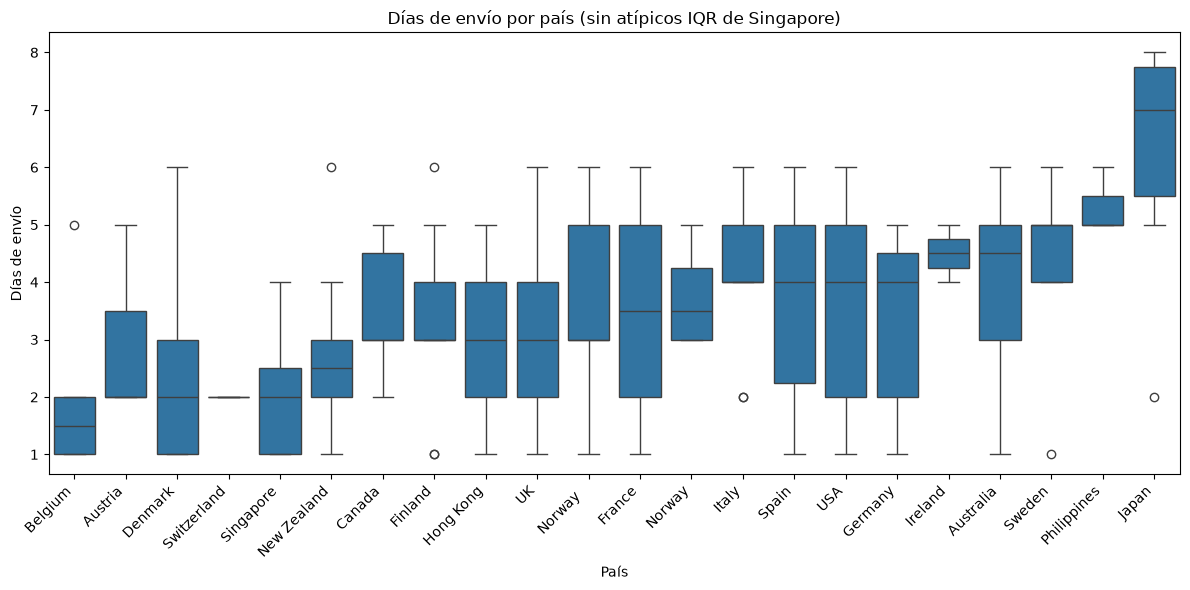

,pedidos,mediana,promedio,minimo,maximo
country,,,,,
Belgium,6,1.5,2.000000,1.0,5.0
Austria,7,2.0,2.857143,2.0,5.0
Denmark,7,2.0,2.428571,1.0,6.0
Switzerland,2,2.0,2.000000,2.0,2.0
Singapore,8,2.0,2.125000,1.0,4.0
New Zealand,14,2.5,2.642857,1.0,6.0
Canada,7,3.0,3.571429,2.0,5.0
Finland,9,3.0,3.222222,1.0,6.0
Hong Kong,2,3.0,3.000000,1.0,5.0


In [49]:
# Separar Singapore del resto
sg = df_biv1[df_biv1["country"] == "Singapore"].copy()
otros = df_biv1[df_biv1["country"] != "Singapore"].copy()

# IQR solo dentro de Singapore
q1 = sg["dias_envio"].quantile(0.25)
q3 = sg["dias_envio"].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

atipicos_sg = sg[~sg["dias_envio"].between(limite_inf, limite_sup)]
sg_limpio = sg[sg["dias_envio"].between(limite_inf, limite_sup)]

print(f"Singapore: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"Límites IQR: [{limite_inf:.1f}, {limite_sup:.1f}]")
print(f"Atípicos eliminados en Singapore: {len(atipicos_sg)}")
if len(atipicos_sg) > 0:
    display(atipicos_sg[["orderNumber", "country", "orderDate", "shippedDate", "dias_envio"]])

df_biv1_sin_atipicos_sg = pd.concat([otros, sg_limpio], ignore_index=True)

resumen_limpio = (
    df_biv1_sin_atipicos_sg.groupby("country")["dias_envio"]
    .agg(pedidos="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_biv1_sin_atipicos_sg,
    x="country",
    y="dias_envio",
    order=resumen_limpio.index.tolist(),
)
plt.title("Días de envío por país (sin atípicos IQR de Singapore)")
plt.xlabel("País")
plt.ylabel("Días de envío")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

resumen_limpio

### Interpretación

Primero que todo tengo que decir que se tuvo que eliminar un dato atípico que tenía Singapore, pues tenía un envío que había tardado 60 días en hacerse. Tras esto, podemos observar los diagramas de caja. Claramente sí hay una variación de las medianas, pues hay unos paises que tienen envíos rápidos entre 1 y 3 días. Pero en el otro extremo destaca Japón, quien su mediana de envío está claramente por encima del resto. De hecho, singapore sin el dato atípico se comporta como uno de los paises con envío rápido.

Parece que el país del cliente sí está asociado, no es una relación perfecta pero puede influir la logística, distancia, etc.


---

## Análisis bivariado 2

**Pregunta:** ¿Hay alguna relación entre el monto comprado y el tiempo que transcurre entre `orderDate` y `shippedDate`?

**Variables:**
- `monto_pedido` (numérica, calculada): suma de `priceEach * quantityOrdered` por pedido (`orderdetails`)
- `dias_envio` (numérica, calculada): `shippedDate - orderDate` en días (`orders`)

**Gráfico:** scatter plot (monto vs días de envío)

**Preparación:** agregar el monto por `orderNumber` en `orderdetails`, unir con `orders`, calcular `dias_envio` y quedarse solo con pedidos ya enviados.

In [50]:
# Monto total por pedido
df_montos = orderdetails.copy()
df_montos["line_total"] = df_montos["priceEach"] * df_montos["quantityOrdered"]

monto_por_pedido = (
    df_montos.groupby("orderNumber", as_index=False)["line_total"]
    .sum()
    .rename(columns={"line_total": "monto_pedido"})
)

# Unir con órdenes y calcular días de envío
df_biv2 = pd.merge(orders, monto_por_pedido, on="orderNumber", how="inner")
df_biv2["orderDate"] = pd.to_datetime(df_biv2["orderDate"])
df_biv2["shippedDate"] = pd.to_datetime(df_biv2["shippedDate"])
df_biv2["dias_envio"] = (df_biv2["shippedDate"] - df_biv2["orderDate"]).dt.days
df_biv2 = df_biv2.dropna(subset=["dias_envio"]).copy()

print("Pedidos usados:", len(df_biv2))
df_biv2[["orderNumber", "monto_pedido", "orderDate", "shippedDate", "dias_envio"]].head(10)

Pedidos usados: 312


,orderNumber,monto_pedido,orderDate,shippedDate,dias_envio
0,10100,10223.83,2003-01-06,2003-01-10,4.0
1,10101,10549.01,2003-01-09,2003-01-11,2.0
2,10102,5494.78,2003-01-10,2003-01-14,4.0
3,10103,50218.95,2003-01-29,2003-02-02,4.0
4,10104,40206.20,2003-01-31,2003-02-01,1.0
5,10105,53959.21,2003-02-11,2003-02-12,1.0
6,10106,52151.81,2003-02-17,2003-02-21,4.0
7,10107,22292.62,2003-02-24,2003-02-26,2.0
8,10108,51001.22,2003-03-03,2003-03-08,5.0
9,10109,25833.14,2003-03-10,2003-03-11,1.0


In [51]:
# Resumen numérico y correlación
print(df_biv2[["monto_pedido", "dias_envio"]].describe())
print("\nCorrelación de Pearson (monto vs días):",
      round(df_biv2["monto_pedido"].corr(df_biv2["dias_envio"]), 4))


       monto_pedido  dias_envio
count    312.000000  312.000000
mean   29259.283462    3.756410
std    15802.211522    3.883135
min      615.450000    1.000000
25%    16740.092500    2.000000
50%    29976.000000    4.000000
75%    41119.265000    5.000000
max    67392.850000   65.000000

Correlación de Pearson (monto vs días): 0.1


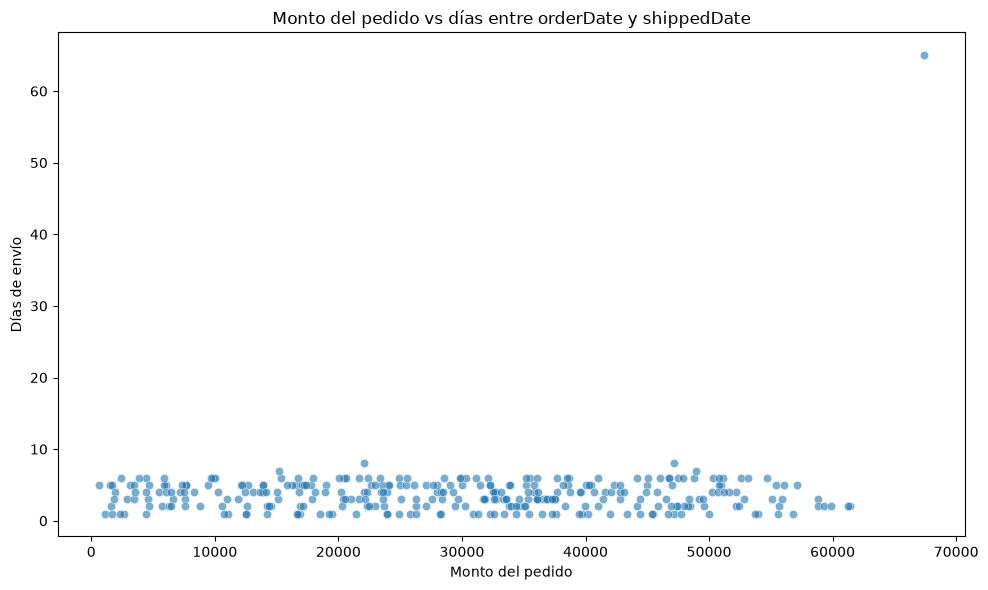

In [52]:
# Scatter: monto del pedido vs días de envío
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_biv2,
    x="monto_pedido",
    y="dias_envio",
    alpha=0.6,
)

plt.title("Monto del pedido vs días entre orderDate y shippedDate")
plt.xlabel("Monto del pedido")
plt.ylabel("Días de envío")
plt.tight_layout()
plt.show()

### Interpretación

Claramente no hay ninguna relación aquí. Son como una nube sin patrón claro. La conclusión es que el tiempo que demora un pedido en ser enviado no tiene nada que ver con la cantidad de dinero que representa la compra. Sin embargo, hay un súper dato atípico que fue el que más dinero representaba y fue el que más días se demoró. Quizá tenga algo que ver, pero al ser un solo dato no podemos sacar conclusiones.


---

## Análisis bivariado 3

**Pregunta:** ¿Hay alguna relación entre el país del cliente y su límite de crédito?

**Variables:**
- `country` (categórica): país del cliente (`customers`)
- `creditLimit` (numérica): límite de crédito del cliente (`customers`)

**Gráfico:** boxplot (país vs `creditLimit`)

**Preparación:** usar `customers` directamente; no hace falta join. Revisar nulos en `creditLimit` si aparecen.

In [53]:
df_biv3 = customers[["customerNumber", "customerName", "country", "creditLimit"]].copy()
df_biv3["creditLimit"] = pd.to_numeric(df_biv3["creditLimit"], errors="coerce")

print("Clientes:", len(df_biv3))
print("Nulos en creditLimit:", df_biv3["creditLimit"].isna().sum())
print("Países distintos:", df_biv3["country"].nunique())
df_biv3.head(10)

Clientes: 122
Nulos en creditLimit: 0
Países distintos: 28


,customerNumber,customerName,country,creditLimit
0,103,Atelier graphique,France,21000.0
1,112,Signal Gift Stores,USA,71800.0
2,114,"Australian Collectors, Co.",Australia,117300.0
3,119,La Rochelle Gifts,France,118200.0
4,121,Baane Mini Imports,Norway,81700.0
5,124,Mini Gifts Distributors Ltd.,USA,210500.0
6,125,Havel & Zbyszek Co,Poland,0.0
7,128,"Blauer See Auto, Co.",Germany,59700.0
8,129,Mini Wheels Co.,USA,64600.0
9,131,Land of Toys Inc.,USA,114900.0


In [54]:
# Resumen por país
resumen_credito = (
    df_biv3.groupby("country")["creditLimit"]
    .agg(clientes="count", mediana="median", promedio="mean", minimo="min", maximo="max")
    .sort_values("mediana")
)
resumen_credito


,clientes,mediana,promedio,minimo,maximo
country,,,,,
Netherlands,1,0.0,0.000000,0.0,0.0
Switzerland,3,0.0,47100.000000,0.0,141300.0
South Africa,1,0.0,0.000000,0.0,0.0
Russia,1,0.0,0.000000,0.0,0.0
Germany,13,0.0,19776.923077,0.0,120400.0
Israel,1,0.0,0.000000,0.0,0.0
Portugal,2,0.0,0.000000,0.0,0.0
Poland,1,0.0,0.000000,0.0,0.0
Ireland,2,34700.0,34700.000000,0.0,69400.0


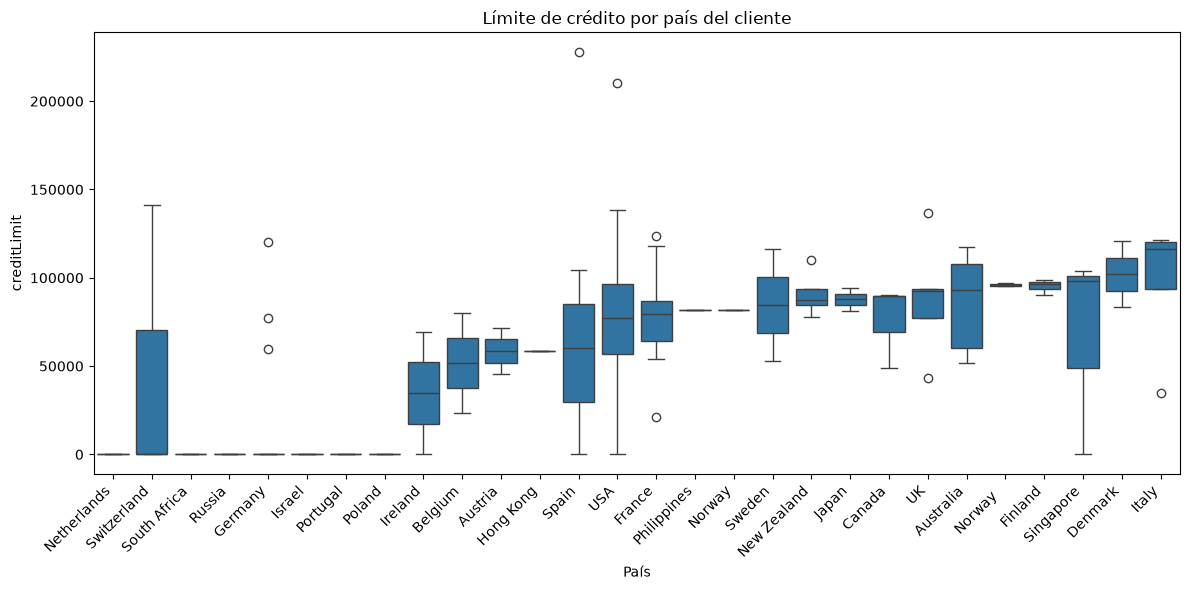

In [55]:
# Boxplot: creditLimit por país
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_biv3,
    x="country",
    y="creditLimit",
    order=resumen_credito.index.tolist(),
)

plt.title("Límite de crédito por país del cliente")
plt.xlabel("País")
plt.ylabel("creditLimit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación

Las medianas del límite del crédito claramente van cambiando dependiendo del pais. Vemos que hay unos paíes a los que no les quieren dar crédito como Netherlands, Switzerland, South Africa, Russia, Germany, entre otras. En total son 8 paises a los que no les suelen ofrecer crédito, lo que puede responder a pocos clientes o cuentas inactivas. Pero por ejemplo en Switzerland y en Germany sí hay clientes a los que les ofrecen un crédito considerable incluso superior a la media general, pero son contados y no represetan una buena proporción en su país. El resto de paises sí van variando de manera gradual, poco uniforme.


---

## Análisis bivariado 4

**Pregunta:** ¿Si hay más stock es porque se vende más el producto o porque se vende menos?

**Variables:**
- `quantityInStock` (numérica): inventario actual del producto (`products`)
- `cantidad_vendida` (numérica, calculada): suma de `quantityOrdered` por producto en `orderdetails`

**Gráfico:** scatter plot (stock vs cantidad vendida)

**Preparación:** agregar ventas por `productCode` en `orderdetails`, unir con `products`.  
**Nota:** el stock es una foto actual; las ventas son históricas. La relación puede existir, pero no prueba causalidad.

In [56]:
# Cantidad vendida histórica por producto
ventas_prod = (
    orderdetails.groupby("productCode", as_index=False)["quantityOrdered"]
    .sum()
    .rename(columns={"quantityOrdered": "cantidad_vendida"})
)

df_biv4 = pd.merge(
    products[["productCode", "productName", "productLine", "quantityInStock"]],
    ventas_prod,
    on="productCode",
    how="left",
)

# Productos sin ventas quedan en 0
df_biv4["cantidad_vendida"] = df_biv4["cantidad_vendida"].fillna(0)
df_biv4["quantityInStock"] = pd.to_numeric(df_biv4["quantityInStock"], errors="coerce")

print("Productos:", len(df_biv4))
df_biv4[["productCode", "productName", "quantityInStock", "cantidad_vendida"]].head(10)

Productos: 110


,productCode,productName,quantityInStock,cantidad_vendida
0,S10_1678,1969 Harley Davidson Ultimate Chopper,7933,1057.0
1,S10_1949,1952 Alpine Renault 1300,7305,961.0
2,S10_2016,1996 Moto Guzzi 1100i,6625,999.0
3,S10_4698,2003 Harley-Davidson Eagle Drag Bike,5582,985.0
4,S10_4757,1972 Alfa Romeo GTA,3252,1030.0
5,S10_4962,1962 LanciaA Delta 16V,6791,932.0
6,S12_1099,1968 Ford Mustang,68,933.0
7,S12_1108,2001 Ferrari Enzo,3619,1019.0
8,S12_1666,1958 Setra Bus,1579,972.0
9,S12_2823,2002 Suzuki XREO,9997,1028.0


In [57]:
# Resumen y correlación
print(df_biv4[["quantityInStock", "cantidad_vendida"]].describe())
corr = df_biv4["quantityInStock"].corr(df_biv4["cantidad_vendida"])
print("\nCorrelación de Pearson (stock vs cantidad vendida):", round(corr, 4))


       quantityInStock  cantidad_vendida
count       110.000000        110.000000
mean       5046.645455        959.236364
std        2939.263668        137.381136
min          15.000000          0.000000
25%        2419.000000        917.000000
50%        5437.500000        962.000000
75%        7599.750000        997.750000
max        9997.000000       1808.000000

Correlación de Pearson (stock vs cantidad vendida): 0.0443


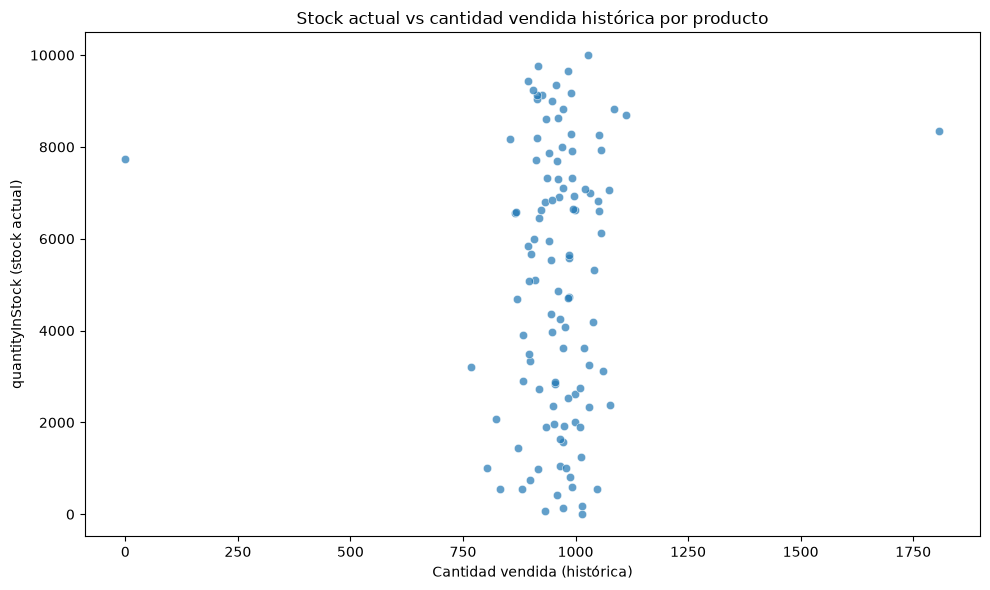

In [58]:
# Scatter: stock vs cantidad vendida
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_biv4,
    x="cantidad_vendida",
    y="quantityInStock",
    alpha=0.7,
)

plt.title("Stock actual vs cantidad vendida histórica por producto")
plt.xlabel("Cantidad vendida (histórica)")
plt.ylabel("quantityInStock (stock actual)")
plt.tight_layout()
plt.show()

### Interpretación

No se puede ver una relación directa entre la cantidad histórica vendida y la cantidad en stock. De hecho, se nota que casi todos los productos se han vendido entre 800 y 1100, pero están distribuidos de manera casi equitativa en su cantidad de stock, salvo por los extremos, que significaría un producto que no se ha vendido casi para nada y aún se tiene mucho stock y el producto estrella que es el que más se vende y coincide con su disponibilidad.


---

## Conclusiones generales

A partir de los cuatro análisis bivariados sobre ClassicModels:

1. **País × días de envío**  
   Parece quesí hay una asociación, hay unos países con envíos más rápidos y otros más lentos, entre estos últimos destacando Japón con una mediana claramente más alta.

2. **Monto del pedido × días de envío**  
   No se observa una relación clara. 

3. **País × límite de crédito**  
   Las medianas de `creditLimit` cambian según el país. Hay un grupo con mediana 0 pero algunos de ellos tienen clientes con crédito alto. En el otro resto de los países, la media varía de forma gradual.

4. **Stock actual × cantidad vendida histórica**  
   No se ve una relación directa. La mayoría de productos vende en un rango similar, de 800 a 1100, pero el stock se reparte de forma muy dispersa.

**Cierre:** de las cuatro preguntas, las relaciones más claras aparecen al cruzar **país** con variables de negocio (envío y crédito). Monto vs envío y stock vs ventas no muestran un patrón fuerte en estos datos. Toda interpretación debe tomarse como exploración descriptiva, no como causa-efecto.
